# Conversion Rate vs. Contact Metrics by Rental Location

This notebook analyzes the relationship between conversion rates and various contact metrics, grouped by rental location (RENT_LOC).

**Charts included:**
1. Conversion Rate vs. % Under 30 Minutes Contact
2. Conversion Rate vs. % Counter Contact
3. Conversion Rate vs. % No Contact
4. Conversion Rate vs. % Under 12 Hours Contact

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
# Load data (INCLUDING UNUSED_IND=1 records)
file_path = '../data/raw/Conversion Data Nov-Dec 2025 (1).xlsx'
df = pd.read_excel(file_path, engine='openpyxl')

# Clean column names
df.columns = df.columns.str.strip()

# Exclude Licensee locations
licensee_count = (df['HTZREGION'] == 'LICENSEE').sum()
df = df[df['HTZREGION'] != 'LICENSEE']
print(f"Excluded {licensee_count:,} Licensee records")

# Note: Including ALL records (UNUSED_IND=0 and UNUSED_IND=1)
unused_count = df['UNUSED_IND'].sum() if 'UNUSED_IND' in df.columns else 0
print(f"Total records (after exclusion): {len(df):,}")
print(f"  - UNUSED_IND=1: {unused_count:,} ({unused_count/len(df)*100:.1f}%)")
print(f"  - UNUSED_IND=0: {len(df)-unused_count:,} ({(len(df)-unused_count)/len(df)*100:.1f}%)")
df.head()

Excluded 4,216 Licensee records
Total records (after exclusion): 64,144
  - UNUSED_IND=1: 13,286 (20.7%)
  - UNUSED_IND=0: 50,858 (79.3%)


,CONFIRM_NUM,RENTER_LAST,CLAIM,CDP,CDP NAME,Week Of,INIT_DATE,4 loC,HTZREGION,SET_STATE,...,KNUM,MONTH,ZIP,CANCEL REASON,INIT_DT_FINAL,DT_FROM_ALPHA1,DAY_DIF,HRS_DIF,MIN_DIF,MMR
1,037-9938451,BETTINGFIELD,161742,0,,2025-11-10,2025-11-14,NaN,EASTERN,GA,...,037-9938451,202511,30518,NO SHOW,2025-11-14 08:30:00,NaT,NaN,NaN,NaN,NO MMR
2,037-9911253,PERRY,300-0674073-2025-PD-11,0,,2025-11-03,2025-11-04,NaN,EASTERN,GA,...,037-9911253,202511,30012,,2025-11-04 08:46:00,2025-11-04 08:58:00,0.0,0.0,12.0,NO MMR
3,037-9965736,JACKACKI,827423GQ,0,,2025-11-24,2025-11-25,NaN,CENTRAL,OH,...,037-9965736,202511,44146,,2025-11-25 11:02:00,NaT,NaN,NaN,NaN,NO MMR
4,037-9928472,JONES,300-0662001-2025,0,,2025-11-10,2025-11-10,NaN,EASTERN,SC,...,037-9928472,202511,29730,,2025-11-10 17:04:00,2025-11-10 17:05:00,0.0,0.0,1.0,NO MMR
5,037-9966347,CASTILLO,698332,0,,2025-11-24,2025-11-25,NaN,CENTRAL,TX,...,037-9966347,202511,77521,,2025-11-25 13:01:00,NaT,NaN,NaN,NaN,NO MMR


In [14]:
# Check contact time and group distributions
print("CONTACT RANGE Distribution:")
print(df['CONTACT RANGE'].value_counts())
print("\nCONTACT_GROUP Distribution:")
print(df['CONTACT_GROUP'].value_counts())

CONTACT RANGE Distribution:
CONTACT RANGE
(a)<30min         18055
(b)31min - 1hr    17671
(c)1-3 hrs        12265
(f)12-24 hrs       6715
NO CONTACT         3266
(d)3-6 hrs         2490
(g)24-48 hrs       1542
(e)6-12 hrs        1488
(h)48+ hrs          652
Name: count, dtype: int64

CONTACT_GROUP Distribution:
CONTACT_GROUP
COUNTER       35641
HRD - OKC     25237
NO CONTACT     3266
Name: count, dtype: int64


In [15]:
# Calculate metrics by RENT_LOC
location_stats = df.groupby('RENT_LOC').agg(
    total_reservations=('RES_ID', 'sum'),
    conversions=('RENT_IND', 'sum'),
    under_30min_count=('CONTACT RANGE', lambda x: (x == '(a)<30min').sum()),
    under_12hr_count=('CONTACT RANGE', lambda x: (x.isin(['(a)<30min', '(b)31min - 1hr', '(c)1-3 hrs', '(d)3-6 hrs', '(e)6-12 hrs'])).sum()),
    no_contact_count=('CONTACT RANGE', lambda x: (x == 'NO CONTACT').sum()),
    counter_count=('CONTACT_GROUP', lambda x: (x == 'COUNTER').sum()),
    total_contacts=('CONTACT RANGE', 'count')
).reset_index()

# Calculate rates
location_stats['conversion_rate'] = (location_stats['conversions'] / location_stats['total_reservations'] * 100)
location_stats['pct_under_30min'] = (location_stats['under_30min_count'] / location_stats['total_contacts'] * 100)
location_stats['pct_under_12hr'] = (location_stats['under_12hr_count'] / location_stats['total_contacts'] * 100)
location_stats['pct_no_contact'] = (location_stats['no_contact_count'] / location_stats['total_contacts'] * 100)
location_stats['pct_counter'] = (location_stats['counter_count'] / location_stats['total_contacts'] * 100)

# Calculate majority GM for each location (handle NaN values)
def get_majority_value(x):
    mode_result = x.mode()
    if len(mode_result) > 0:
        return mode_result.iloc[0]
    return 'Unknown'

majority_gm = df.groupby('RENT_LOC')['GENERAL_MGR'].agg(get_majority_value).reset_index()
majority_gm.columns = ['RENT_LOC', 'majority_gm']
majority_gm['majority_gm'] = majority_gm['majority_gm'].fillna('Unknown')
location_stats = location_stats.merge(majority_gm, on='RENT_LOC', how='left')
location_stats['majority_gm'] = location_stats['majority_gm'].fillna('Unknown')

# Filter to locations with meaningful volume (at least 50 reservations)
location_stats_filtered = location_stats[location_stats['total_reservations'] >= 50].copy()

print(f"Total locations: {len(location_stats)}")
print(f"Locations with 50+ reservations: {len(location_stats_filtered)}")

# Get all unique GMs and create color mapping
all_gms = location_stats_filtered['majority_gm'].unique()
n_gms = len(all_gms)
print(f"\nUnique General Managers: {n_gms}")

# Generate distinct colors for all GMs using a combination of colormaps
import matplotlib.cm as cm
import numpy as np

# Use multiple colormaps to get enough distinct colors
colors_list = []
colormaps = ['tab20', 'tab20b', 'tab20c', 'Set1', 'Set2', 'Set3', 'Paired', 'Dark2']
for cmap_name in colormaps:
    cmap = cm.get_cmap(cmap_name)
    n_colors = cmap.N if hasattr(cmap, 'N') else 20
    for i in range(min(n_colors, 20)):
        colors_list.append(cmap(i / max(n_colors - 1, 1)))
    if len(colors_list) >= n_gms:
        break

# Build gm_colors dict for all GMs
gm_colors = {gm: colors_list[i % len(colors_list)] for i, gm in enumerate(sorted(all_gms))}

# Use majority_gm directly as the color group (no "Other" grouping)
location_stats_filtered['gm_color_group'] = location_stats_filtered['majority_gm']

print(f"\nMajority GM distribution (top 10):")
print(location_stats_filtered['majority_gm'].value_counts().head(10))

location_stats_filtered.head(10)

Total locations: 929
Locations with 50+ reservations: 574

Unique General Managers: 50

Majority GM distribution (top 10):
majority_gm
JOSHUA RODERIQUES    36
SCOTT MILLER         31
SASHA JORDAN         26
JD RICE              25
TODD STARBUCK        21
JADE GOUGH           21
JUSTIN BRIETZKE      20
LAURA JOYCE          19
KEN SCHRICK          19
JAMIE HISH           18
Name: count, dtype: int64


/var/folders/x0/6cfvvvlj3g7fwgfj3fwm8zgh0000gn/T/ipykernel_21676/393779408.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


,RENT_LOC,total_reservations,conversions,under_30min_count,under_12hr_count,no_contact_count,counter_count,total_contacts,conversion_rate,pct_under_30min,pct_under_12hr,pct_no_contact,pct_counter,majority_gm,gm_color_group
0,- OKC RENTAL CONTROL UNIT,442,2,47,213,178,50,442,0.452489,10.633484,48.190045,40.271493,11.312217,STEPHANIE WEEKS,STEPHANIE WEEKS
1,1185-18 - NEWPORT BEACH HLE,60,36,12,40,2,45,60,60.000000,20.000000,66.666667,3.333333,75.000000,JOSEPH ARRIARAN,JOSEPH ARRIARAN
3,1507-01 - VETERANS AIRPORT HLE,83,41,46,81,2,64,83,49.397590,55.421687,97.590361,2.409639,77.108434,BEN LAVERY,BEN LAVERY
5,1545-17 - AKRON/CANTON AP,53,32,5,47,1,17,53,60.377358,9.433962,88.679245,1.886792,32.075472,JUSTIN BRIETZKE,JUSTIN BRIETZKE
6,1611-01 - MUNICIPAL AP,69,49,29,64,2,47,69,71.014493,42.028986,92.753623,2.898551,68.115942,SASHA JORDAN,SASHA JORDAN
10,1715-19 - BARNSTABLE CNTY AP,89,43,14,62,3,40,89,48.314607,15.730337,69.662921,3.370787,44.943820,JOSHUA RODERIQUES,JOSHUA RODERIQUES
12,1801-19 - AMTRAK HLES,102,44,22,81,10,48,102,43.137255,21.568627,79.411765,9.803922,47.058824,JD RICE,JD RICE
15,1861-02 - LYNCHBURG REGIONAL AP,65,40,38,59,1,46,65,61.538462,58.461538,90.769231,1.538462,70.769231,SCOTT MILLER,SCOTT MILLER
24,2163-30 - YUMA INTL AP,52,26,4,37,3,11,52,50.000000,7.692308,71.153846,5.769231,21.153846,SAM SCHLUETER,SAM SCHLUETER
27,2204-12 - STATE STREET HLE,299,92,67,235,23,130,299,30.769231,22.408027,78.595318,7.692308,43.478261,MATT JOHNSON,MATT JOHNSON


## Chart 1: Conversion Rate vs. % Under 30 Minutes Contact

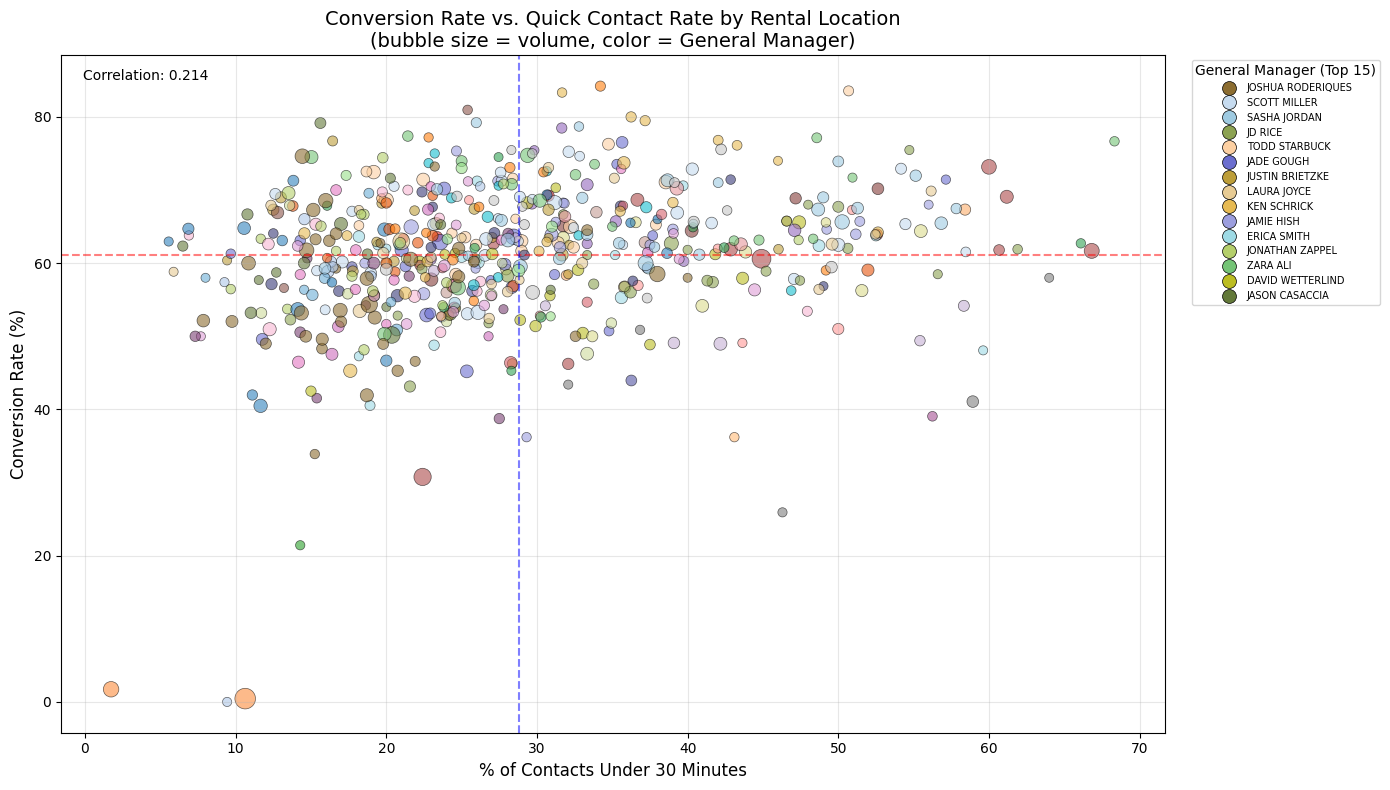

In [16]:
# Create scatter plot
fig, ax = plt.subplots(figsize=(14, 8))

# Size points by volume
sizes = location_stats_filtered['total_reservations'] / location_stats_filtered['total_reservations'].max() * 200 + 20

# Color points by majority GM
colors = location_stats_filtered['gm_color_group'].map(gm_colors)

scatter = ax.scatter(
    location_stats_filtered['pct_under_30min'],
    location_stats_filtered['conversion_rate'],
    s=sizes,
    alpha=0.6,
    c=colors.tolist(),
    edgecolors='black',
    linewidth=0.5
)

# Add legend for top GMs only (by location count)
top_gms_for_legend = location_stats_filtered['majority_gm'].value_counts().head(15).index.tolist()
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=gm_colors[gm], 
                              markersize=10, label=gm, markeredgecolor='black', markeredgewidth=0.5)
                  for gm in top_gms_for_legend]
ax.legend(handles=legend_handles, title='General Manager (Top 15)', loc='upper left', fontsize=7, bbox_to_anchor=(1.02, 1))

# Labels and title
ax.set_xlabel('% of Contacts Under 30 Minutes', fontsize=12)
ax.set_ylabel('Conversion Rate (%)', fontsize=12)
ax.set_title('Conversion Rate vs. Quick Contact Rate by Rental Location\n(bubble size = volume, color = General Manager)', fontsize=14)

# Add grid
ax.grid(True, alpha=0.3)

# Add average lines
avg_conversion = location_stats_filtered['conversion_rate'].mean()
avg_under30 = location_stats_filtered['pct_under_30min'].mean()
ax.axhline(y=avg_conversion, color='red', linestyle='--', alpha=0.5, label=f'Avg Conversion: {avg_conversion:.1f}%')
ax.axvline(x=avg_under30, color='blue', linestyle='--', alpha=0.5, label=f'Avg <30min: {avg_under30:.1f}%')

# Add correlation coefficient
corr = location_stats_filtered['pct_under_30min'].corr(location_stats_filtered['conversion_rate'])
ax.text(0.02, 0.98, f'Correlation: {corr:.3f}', transform=ax.transAxes, fontsize=10, verticalalignment='top')

plt.tight_layout()
plt.show()

In [17]:
# Calculate correlations for all metrics
correlations = {
    '% Under 30min': location_stats_filtered['pct_under_30min'].corr(location_stats_filtered['conversion_rate']),
    '% Under 12hr': location_stats_filtered['pct_under_12hr'].corr(location_stats_filtered['conversion_rate']),
    '% Counter': location_stats_filtered['pct_counter'].corr(location_stats_filtered['conversion_rate']),
    '% No Contact': location_stats_filtered['pct_no_contact'].corr(location_stats_filtered['conversion_rate'])
}

print("Correlations with Conversion Rate:")
for metric, corr in correlations.items():
    print(f"  {metric}: {corr:.3f}")

Correlations with Conversion Rate:
  % Under 30min: 0.214
  % Under 12hr: 0.417
  % Counter: 0.145
  % No Contact: -0.438


## Chart 2: Conversion Rate vs. % Counter Contact

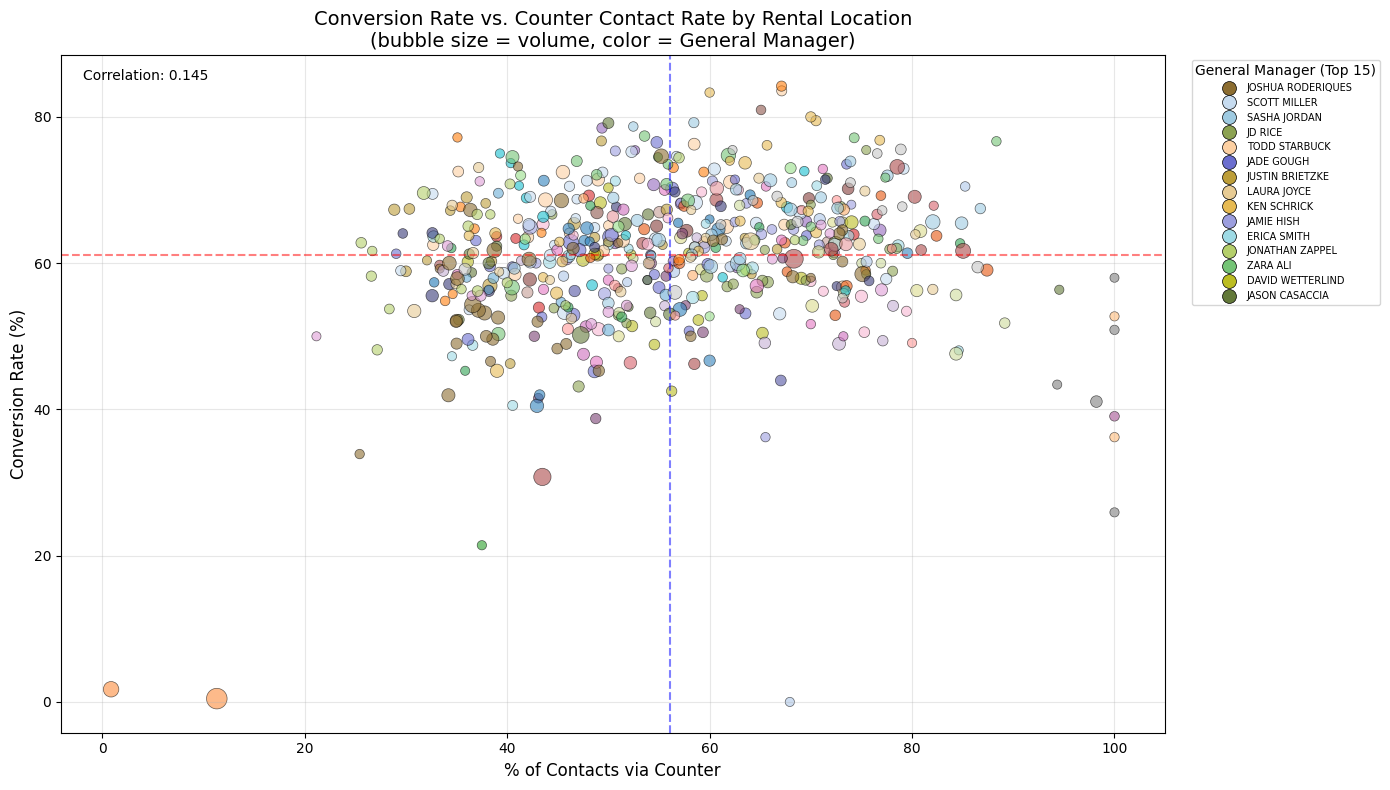

In [18]:
# Chart 2: Conversion Rate vs. % Counter
fig, ax = plt.subplots(figsize=(14, 8))

sizes = location_stats_filtered['total_reservations'] / location_stats_filtered['total_reservations'].max() * 200 + 20

# Color points by majority GM
colors = location_stats_filtered['gm_color_group'].map(gm_colors)

scatter = ax.scatter(
    location_stats_filtered['pct_counter'],
    location_stats_filtered['conversion_rate'],
    s=sizes,
    alpha=0.6,
    c=colors.tolist(),
    edgecolors='black',
    linewidth=0.5
)

# Add legend for top GMs only
top_gms_for_legend = location_stats_filtered['majority_gm'].value_counts().head(15).index.tolist()
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=gm_colors[gm], 
                              markersize=10, label=gm, markeredgecolor='black', markeredgewidth=0.5)
                  for gm in top_gms_for_legend]
ax.legend(handles=legend_handles, title='General Manager (Top 15)', loc='upper left', fontsize=7, bbox_to_anchor=(1.02, 1))

ax.set_xlabel('% of Contacts via Counter', fontsize=12)
ax.set_ylabel('Conversion Rate (%)', fontsize=12)
ax.set_title('Conversion Rate vs. Counter Contact Rate by Rental Location\n(bubble size = volume, color = General Manager)', fontsize=14)

ax.grid(True, alpha=0.3)

avg_counter = location_stats_filtered['pct_counter'].mean()
ax.axhline(y=avg_conversion, color='red', linestyle='--', alpha=0.5, label=f'Avg Conversion: {avg_conversion:.1f}%')
ax.axvline(x=avg_counter, color='blue', linestyle='--', alpha=0.5, label=f'Avg Counter: {avg_counter:.1f}%')

# Add correlation coefficient
corr = location_stats_filtered['pct_counter'].corr(location_stats_filtered['conversion_rate'])
ax.text(0.02, 0.98, f'Correlation: {corr:.3f}', transform=ax.transAxes, fontsize=10, verticalalignment='top')

plt.tight_layout()
plt.show()

## Chart 3: Conversion Rate vs. % No Contact

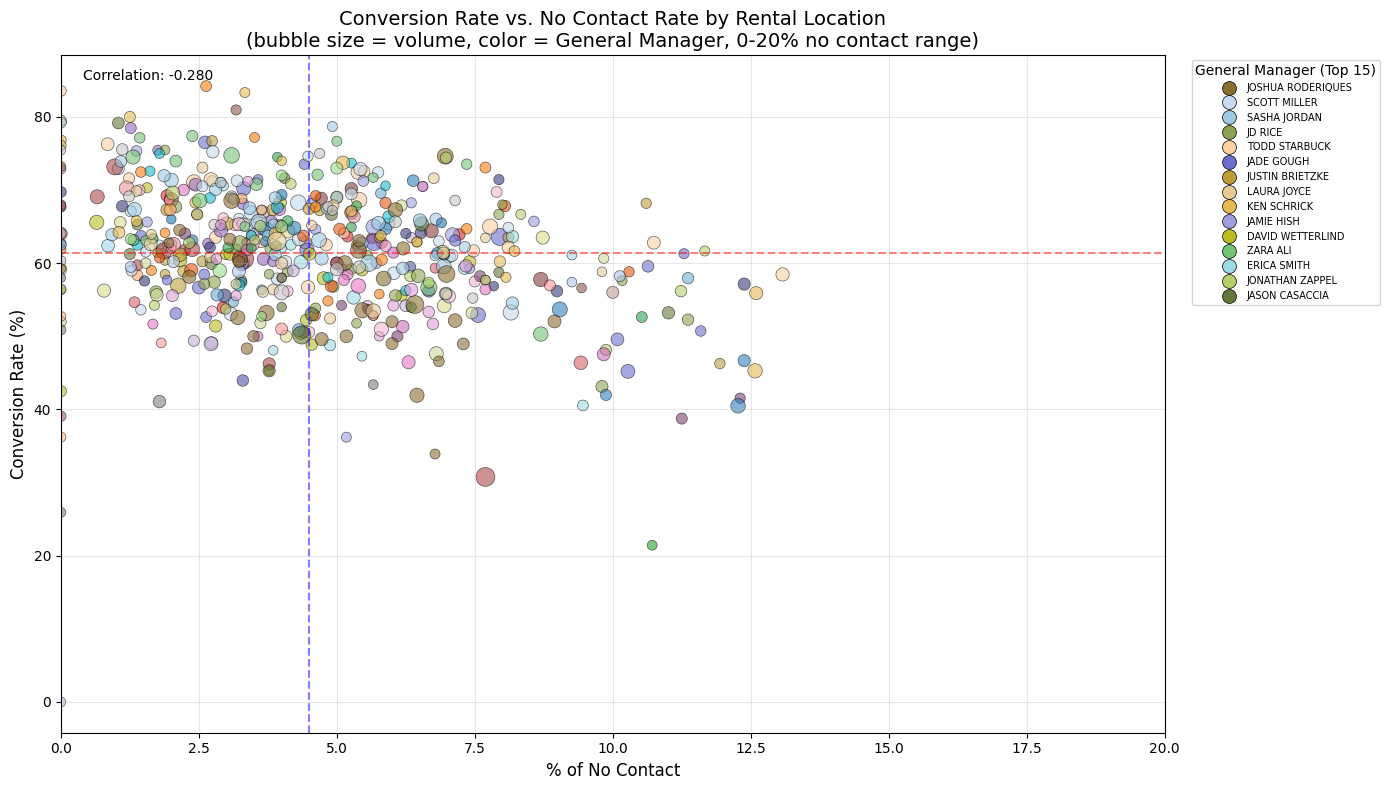

Showing 572 locations with <=20% no contact (excluded 2 locations)


In [19]:
# Chart 3: Conversion Rate vs. % No Contact (0-20% range)
fig, ax = plt.subplots(figsize=(14, 8))

# Filter to locations with <=20% no contact
no_contact_filtered = location_stats_filtered[location_stats_filtered['pct_no_contact'] <= 20].copy()

sizes = no_contact_filtered['total_reservations'] / no_contact_filtered['total_reservations'].max() * 200 + 20

# Color points by majority GM
colors = no_contact_filtered['gm_color_group'].map(gm_colors)

scatter = ax.scatter(
    no_contact_filtered['pct_no_contact'],
    no_contact_filtered['conversion_rate'],
    s=sizes,
    alpha=0.6,
    c=colors.tolist(),
    edgecolors='black',
    linewidth=0.5
)

# Add legend for top GMs only
top_gms_for_legend = no_contact_filtered['majority_gm'].value_counts().head(15).index.tolist()
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=gm_colors[gm], 
                              markersize=10, label=gm, markeredgecolor='black', markeredgewidth=0.5)
                  for gm in top_gms_for_legend]
ax.legend(handles=legend_handles, title='General Manager (Top 15)', loc='upper left', fontsize=7, bbox_to_anchor=(1.02, 1))

ax.set_xlabel('% of No Contact', fontsize=12)
ax.set_ylabel('Conversion Rate (%)', fontsize=12)
ax.set_title('Conversion Rate vs. No Contact Rate by Rental Location\n(bubble size = volume, color = General Manager, 0-20% no contact range)', fontsize=14)

# Set x-axis limits
ax.set_xlim(0, 20)

ax.grid(True, alpha=0.3)

avg_no_contact = no_contact_filtered['pct_no_contact'].mean()
avg_conv_no_contact = no_contact_filtered['conversion_rate'].mean()
ax.axhline(y=avg_conv_no_contact, color='red', linestyle='--', alpha=0.5, label=f'Avg Conversion: {avg_conv_no_contact:.1f}%')
ax.axvline(x=avg_no_contact, color='blue', linestyle='--', alpha=0.5, label=f'Avg No Contact: {avg_no_contact:.1f}%')

# Show correlation for filtered data
corr = no_contact_filtered['pct_no_contact'].corr(no_contact_filtered['conversion_rate'])
ax.text(0.02, 0.98, f'Correlation: {corr:.3f}', transform=ax.transAxes, fontsize=10, verticalalignment='top')

plt.tight_layout()
plt.show()

print(f"Showing {len(no_contact_filtered)} locations with <=20% no contact (excluded {len(location_stats_filtered) - len(no_contact_filtered)} locations)")

## Chart 4: Conversion Rate vs. % Under 12 Hours Contact

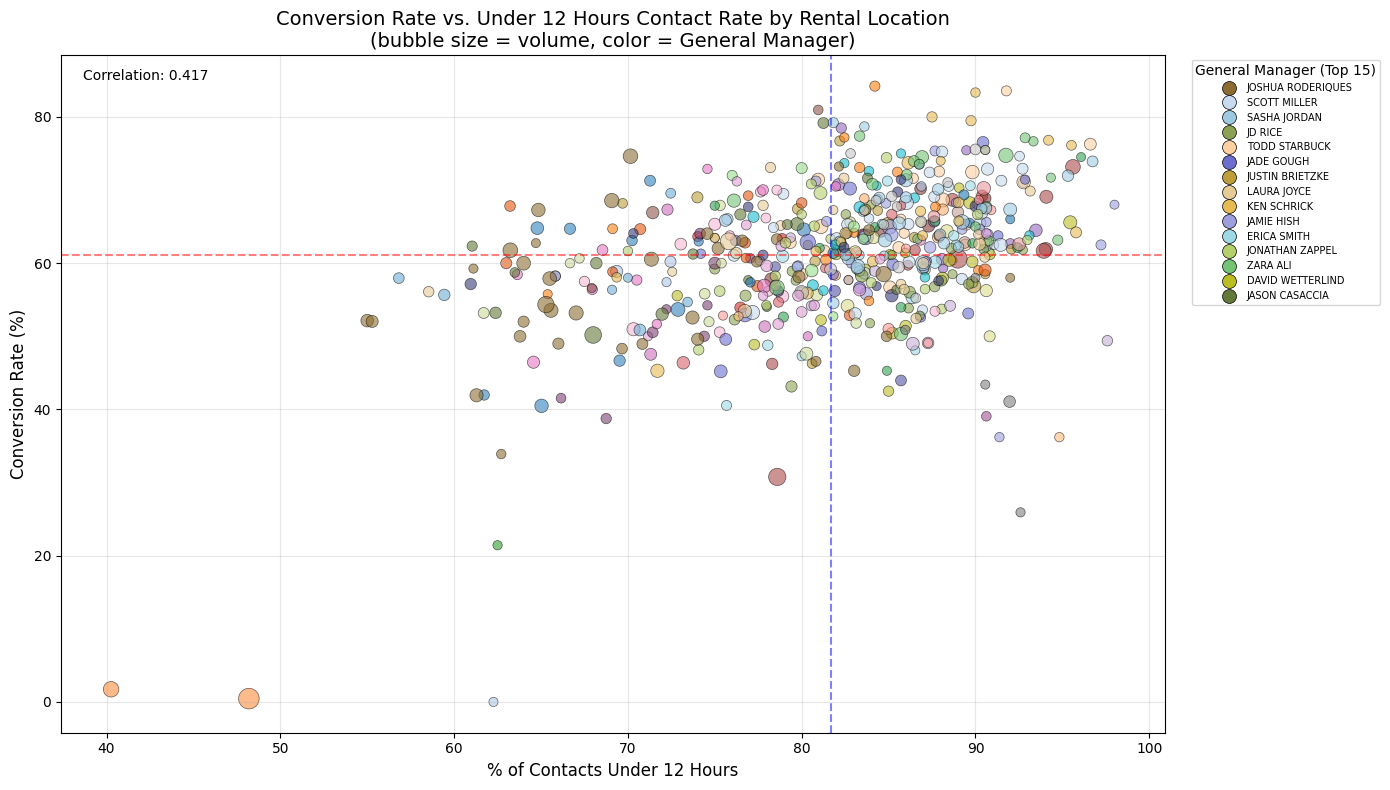

In [20]:
# Chart 4: Conversion Rate vs. % Under 12 Hours
fig, ax = plt.subplots(figsize=(14, 8))

sizes = location_stats_filtered['total_reservations'] / location_stats_filtered['total_reservations'].max() * 200 + 20

# Color points by majority GM
colors = location_stats_filtered['gm_color_group'].map(gm_colors)

scatter = ax.scatter(
    location_stats_filtered['pct_under_12hr'],
    location_stats_filtered['conversion_rate'],
    s=sizes,
    alpha=0.6,
    c=colors.tolist(),
    edgecolors='black',
    linewidth=0.5
)

# Add legend for top GMs only
top_gms_for_legend = location_stats_filtered['majority_gm'].value_counts().head(15).index.tolist()
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=gm_colors[gm], 
                              markersize=10, label=gm, markeredgecolor='black', markeredgewidth=0.5)
                  for gm in top_gms_for_legend]
ax.legend(handles=legend_handles, title='General Manager (Top 15)', loc='upper left', fontsize=7, bbox_to_anchor=(1.02, 1))

ax.set_xlabel('% of Contacts Under 12 Hours', fontsize=12)
ax.set_ylabel('Conversion Rate (%)', fontsize=12)
ax.set_title('Conversion Rate vs. Under 12 Hours Contact Rate by Rental Location\n(bubble size = volume, color = General Manager)', fontsize=14)

ax.grid(True, alpha=0.3)

avg_under_12hr = location_stats_filtered['pct_under_12hr'].mean()
ax.axhline(y=avg_conversion, color='red', linestyle='--', alpha=0.5, label=f'Avg Conversion: {avg_conversion:.1f}%')
ax.axvline(x=avg_under_12hr, color='blue', linestyle='--', alpha=0.5, label=f'Avg <12hr: {avg_under_12hr:.1f}%')

# Add correlation coefficient
corr = location_stats_filtered['pct_under_12hr'].corr(location_stats_filtered['conversion_rate'])
ax.text(0.02, 0.98, f'Correlation: {corr:.3f}', transform=ax.transAxes, fontsize=10, verticalalignment='top')

plt.tight_layout()
plt.show()

In [21]:
# Identify quadrants
location_stats_filtered['quadrant'] = 'Unknown'
location_stats_filtered.loc[
    (location_stats_filtered['conversion_rate'] >= avg_conversion) & 
    (location_stats_filtered['pct_under_30min'] >= avg_under30), 'quadrant'] = 'High Conv + Fast Contact'
location_stats_filtered.loc[
    (location_stats_filtered['conversion_rate'] >= avg_conversion) & 
    (location_stats_filtered['pct_under_30min'] < avg_under30), 'quadrant'] = 'High Conv + Slow Contact'
location_stats_filtered.loc[
    (location_stats_filtered['conversion_rate'] < avg_conversion) & 
    (location_stats_filtered['pct_under_30min'] >= avg_under30), 'quadrant'] = 'Low Conv + Fast Contact'
location_stats_filtered.loc[
    (location_stats_filtered['conversion_rate'] < avg_conversion) & 
    (location_stats_filtered['pct_under_30min'] < avg_under30), 'quadrant'] = 'Low Conv + Slow Contact'

print("Locations by Quadrant:")
location_stats_filtered['quadrant'].value_counts()

Locations by Quadrant:


quadrant
Low Conv + Slow Contact     181
High Conv + Fast Contact    164
High Conv + Slow Contact    149
Low Conv + Fast Contact      80
Name: count, dtype: int64

In [22]:
# Top 10 locations by volume with all metrics
print("Top 10 Locations by Volume:")
location_stats_filtered.nlargest(10, 'total_reservations')[
    ['RENT_LOC', 'total_reservations', 'conversion_rate', 
     'pct_under_30min', 'pct_under_12hr', 'pct_counter', 'pct_no_contact']
].round(1)

Top 10 Locations by Volume:


,RENT_LOC,total_reservations,conversion_rate,pct_under_30min,pct_under_12hr,pct_counter,pct_no_contact
0,- OKC RENTAL CONTROL UNIT,442,0.5,10.6,48.2,11.3,40.3
84,5311-01 - OAK PARK HLE,363,60.6,44.9,89.0,68.3,3.3
27,2204-12 - STATE STREET HLE,299,30.8,22.4,78.6,43.5,7.7
749,7771-01 - WEST SPRINGFIELD HLE,281,63.0,21.0,75.8,64.1,3.9
530,7351-03 - ELLIS STREET HLE,275,50.2,20.4,68.0,47.3,4.4
733,7749-01 - WORCESTER HLE,265,54.3,18.9,65.3,36.6,6.4
45,4838-06 - JOPPA RD HLE,239,63.6,28.5,83.7,50.2,7.9
928,OK2 - OKC RES CENTER,231,1.7,1.7,40.3,0.9,48.9
288,5894-02 - ODONNELL CATONSVILLE,229,62.9,23.6,80.3,46.3,5.7
720,7735-01 - CHELMSFORD HLE,229,58.5,38.0,84.7,75.1,7.0
